In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [70]:
# Retreiving the dataset
group1_df = pd.read_csv("data/KSI_Project Dataset.csv")


In [71]:
group1_df.head(5)

,OBJECTID,INDEX,ACCNUM,DATE,TIME,STREET1,STREET2,OFFSET,ROAD_CLASS,DISTRICT,...,REDLIGHT,ALCOHOL,DISABILITY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,DIVISION,x,y
0,1,3389067,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,...,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06
1,2,3389068,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,...,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06
2,3,3389069,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,...,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06
3,4,3389070,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,...,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06
4,5,3389071,893184.0,1/1/2006 10:00:00 AM,236,WOODBINE AVE,O CONNOR DR,NaN,Major Arterial,Toronto and East York,...,NaN,Yes,NaN,60,Woodbine-Lumsden,60,Woodbine-Lumsden (60),D55,635468.3685,4.839881e+06


In [72]:
group1_df.shape

(18957, 54)

In [73]:
# Columns findings
group1_df.info()


<class 'pandas.DataFrame'>
RangeIndex: 18957 entries, 0 to 18956
Data columns (total 54 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   OBJECTID           18957 non-null  int64  
 1   INDEX              18957 non-null  int64  
 2   ACCNUM             14027 non-null  float64
 3   DATE               18957 non-null  str    
 4   TIME               18957 non-null  int64  
 5   STREET1            18957 non-null  str    
 6   STREET2            17251 non-null  str    
 7   OFFSET             3820 non-null   str    
 8   ROAD_CLASS         18471 non-null  str    
 9   DISTRICT           18728 non-null  str    
 10  LATITUDE           18957 non-null  float64
 11  LONGITUDE          18957 non-null  float64
 12  ACCLOC             13501 non-null  str    
 13  TRAFFCTL           18882 non-null  str    
 14  VISIBILITY         18933 non-null  str    
 15  LIGHT              18953 non-null  str    
 16  RDSFCOND           18928 non-null

In [74]:
# null values :
group1_df.isnull().sum().sum()

np.int64(384930)

In [75]:
null_cols = group1_df.columns[group1_df.isnull().any()]     # any columns which has null values
(group1_df[null_cols].isnull().sum()/18957)*100    # Total nulls in each of them.

ACCNUM           26.006225
STREET2           8.999314
OFFSET           79.849132
ROAD_CLASS        2.563697
DISTRICT          1.207997
ACCLOC           28.780925
TRAFFCTL          0.395632
VISIBILITY        0.126602
LIGHT             0.021100
RDSFCOND          0.152978
ACCLASS           0.005275
IMPACTYPE         0.142428
INVTYPE           0.084402
INJURY           46.932532
FATAL_NO         95.410666
INITDIR          27.836683
VEHTYPE          18.394261
MANOEUVER        41.952841
DRIVACT          49.000369
DRIVCOND         49.010919
PEDTYPE          82.966714
PEDACT           82.977264
PEDCOND          82.877038
CYCLISTYPE       95.753548
CYCACT           95.769373
CYCCOND          95.779923
PEDESTRIAN       59.445060
CYCLIST          89.523659
AUTOMOBILE        9.110091
MOTORCYCLE       91.116738
TRUCK            93.833412
TRSN_CITY_VEH    93.944189
EMERG_VEH        99.741520
PASSENGER        62.108983
SPEEDING         85.788891
AG_DRIV          48.114153
REDLIGHT         91.681173
A

In [76]:
len(null_cols)      # 39 columns have null values alteast once or more than it 

39

In [77]:
group1_df.nunique()  # finding the target column

OBJECTID             18957
INDEX                18957
ACCNUM                4955
DATE                  4128
TIME                  1341
STREET1               1942
STREET2               2822
OFFSET                 494
ROAD_CLASS              11
DISTRICT                 4
LATITUDE              4783
LONGITUDE             5202
ACCLOC                  10
TRAFFCTL                10
VISIBILITY               8
LIGHT                    9
RDSFCOND                 9
ACCLASS                  3
IMPACTYPE               10
INVTYPE                 19
INVAGE                  21
INJURY                   4
FATAL_NO                78
INITDIR                  5
VEHTYPE                 32
MANOEUVER               16
DRIVACT                 13
DRIVCOND                10
PEDTYPE                 16
PEDACT                  15
PEDCOND                 10
CYCLISTYPE              22
CYCACT                  11
CYCCOND                 10
PEDESTRIAN               1
CYCLIST                  1
AUTOMOBILE               1
M

In [78]:
group1_df['ACCLASS'].unique() # Target columns

<StringArray>
['Non-Fatal Injury', 'Fatal', 'Property Damage O', nan]
Length: 4, dtype: str

In [79]:
group1_df['ACCLASS'].value_counts()

ACCLASS
Non-Fatal Injury     16268
Fatal                 2670
Property Damage O       18
Name: count, dtype: int64

In [80]:
# basic statistics
group1_df.describe()

,OBJECTID,INDEX,ACCNUM,TIME,LATITUDE,LONGITUDE,FATAL_NO,x,y
count,18957.000000,1.895700e+04,1.402700e+04,18957.000000,18957.000000,18957.000000,870.000000,18957.000000,1.895700e+04
mean,9479.000000,3.994181e+07,5.576714e+08,1364.956428,43.710299,-79.396490,28.752874,629181.568576,4.840951e+06
std,5472.558862,3.749731e+07,1.180026e+09,631.310388,0.056294,0.104484,17.657001,8364.337712,6.324585e+03
min,1.000000,3.363207e+06,2.530100e+04,0.000000,43.589678,-79.638390,1.000000,609625.702600,4.827328e+06
25%,4740.000000,5.408154e+06,1.034561e+06,924.000000,43.661727,-79.471469,14.000000,623177.000800,4.835532e+06
50%,9479.000000,7.820656e+06,1.220029e+06,1450.000000,43.702346,-79.397388,27.500000,629199.077800,4.840070e+06
75%,14218.000000,8.092292e+07,1.386958e+06,1852.000000,43.755945,-79.318286,42.000000,635424.041900,4.846036e+06
max,18957.000000,8.180752e+07,4.008024e+09,2359.000000,43.855445,-79.122974,78.000000,651024.087800,4.857444e+06


In [81]:
# stats for the catgorical columns
group1_df.describe(include='str')

,DATE,STREET1,STREET2,OFFSET,ROAD_CLASS,DISTRICT,ACCLOC,TRAFFCTL,VISIBILITY,LIGHT,...,SPEEDING,AG_DRIV,REDLIGHT,ALCOHOL,DISABILITY,HOOD_158,NEIGHBOURHOOD_158,HOOD_140,NEIGHBOURHOOD_140,DIVISION
count,18957,18957,17251,3820,18471,18728,13501,18882,18933,18953,...,2694,9836,1577,808,493,18957,18957,18957,18957,18957
unique,4128,1942,2822,494,11,4,10,10,8,9,...,1,1,1,1,1,159,159,141,141,17
top,8/17/2014 8:00:00 AM,YONGE ST,BATHURST ST,10 m West of,Major Arterial,Toronto and East York,At Intersection,No Control,Clear,Daylight,...,Yes,Yes,Yes,Yes,Yes,1,West Humber-Clairville,77,Waterfront Communities-The Island (77),D42
freq,35,403,156,61,13376,6328,8774,9021,16373,10779,...,2694,9836,1577,808,493,597,597,740,740,1813


In [82]:
group1_df['FATAL'] = group1_df['FATAL_NO'].apply(lambda x: 1 if x > 0 else 0) #If 1 it is fatal, if 0 it is non-fatal

In [83]:
missing = group1_df.isnull().sum()
missing_percent = (missing / len(group1_df)) * 100

In [84]:
#Finding the missing data

# Missing values count
missing = group1_df.isnull().sum()

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_percent
}).sort_values(by='Missing %', ascending=False)

In [85]:
print(missing_df)

                   Missing Count  Missing %
EMERG_VEH                  18908  99.741520
DISABILITY                 18464  97.399378
CYCCOND                    18157  95.779923
CYCACT                     18155  95.769373
CYCLISTYPE                 18152  95.753548
ALCOHOL                    18149  95.737722
FATAL_NO                   18087  95.410666
TRSN_CITY_VEH              17809  93.944189
TRUCK                      17788  93.833412
REDLIGHT                   17380  91.681173
MOTORCYCLE                 17273  91.116738
CYCLIST                    16971  89.523659
SPEEDING                   16263  85.788891
PEDACT                     15730  82.977264
PEDTYPE                    15728  82.966714
PEDCOND                    15711  82.877038
OFFSET                     15137  79.849132
PASSENGER                  11774  62.108983
PEDESTRIAN                 11269  59.445060
DRIVCOND                    9291  49.010919
DRIVACT                     9289  49.000369
AG_DRIV                     9121

In [86]:
sns.set(style="whitegrid")

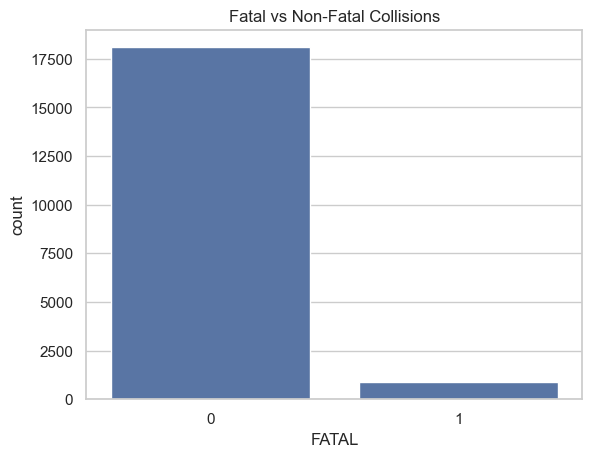

In [87]:
sns.countplot(data=group1_df, x='FATAL')
plt.title("Fatal vs Non-Fatal Collisions")
plt.show()

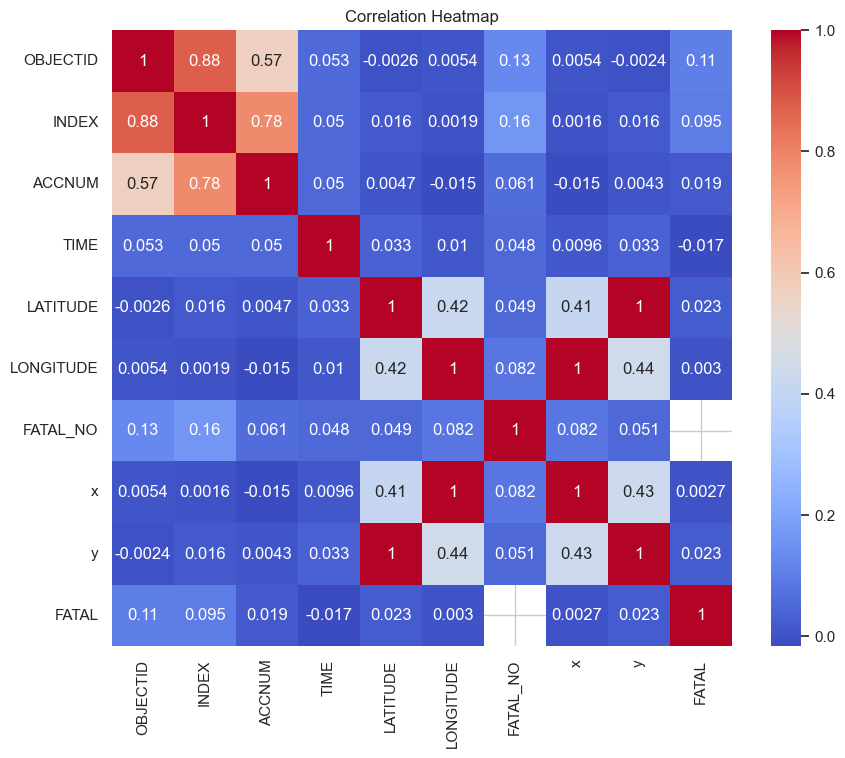

In [88]:
plt.figure(figsize=(10,8))
sns.heatmap(group1_df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

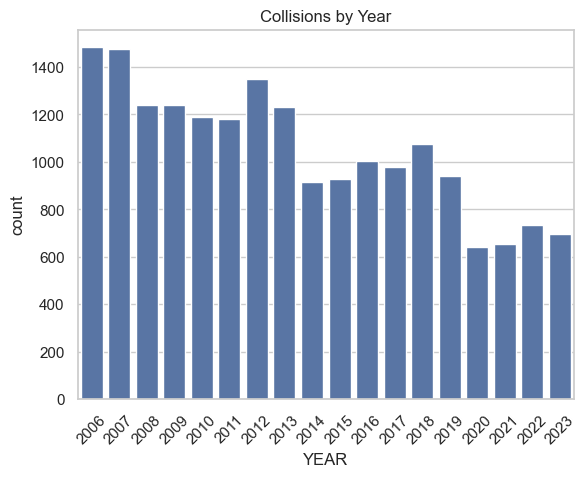

In [89]:
group1_df['YEAR'] = pd.to_datetime(group1_df['DATE']).dt.year

sns.countplot(data=group1_df, x='YEAR')
plt.xticks(rotation=45)
plt.title("Collisions by Year")
plt.show()

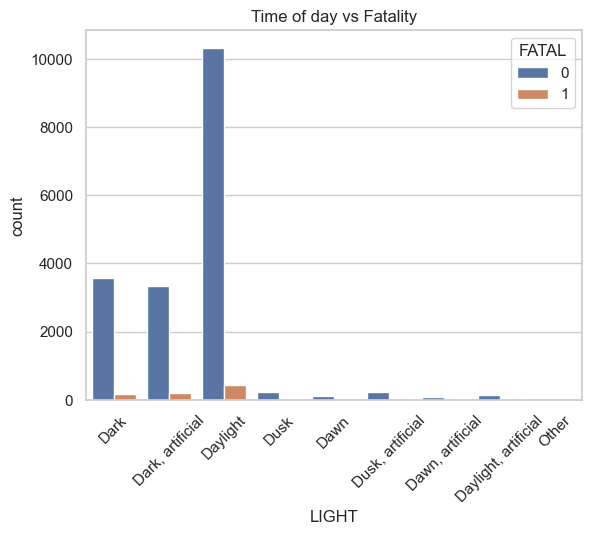

In [90]:
sns.countplot(data=group1_df, x='LIGHT', hue='FATAL')
plt.xticks(rotation=45)
plt.title("Time of day vs Fatality")
plt.show()

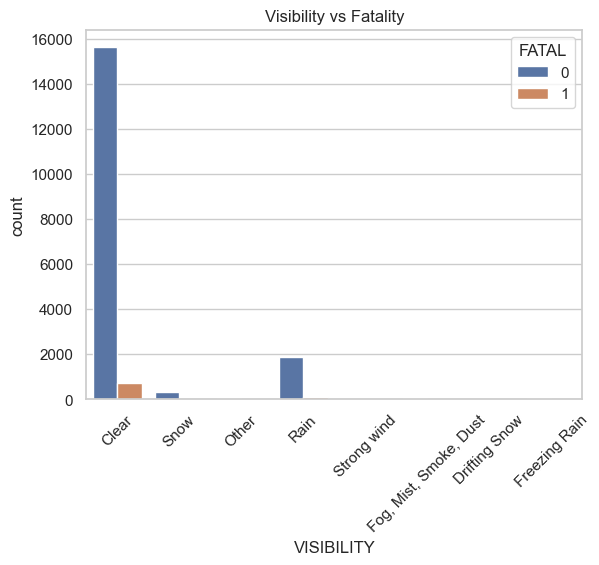

In [91]:
sns.countplot(data=group1_df, x='VISIBILITY', hue='FATAL')
plt.xticks(rotation=45)
plt.title("Visibility vs Fatality")
plt.show()

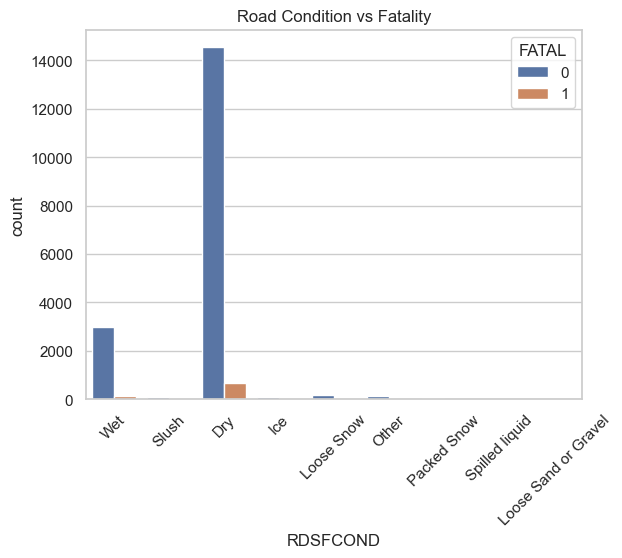

In [92]:
sns.countplot(data=group1_df, x='RDSFCOND', hue='FATAL')
plt.xticks(rotation=45)
plt.title("Road Condition vs Fatality")
plt.show()

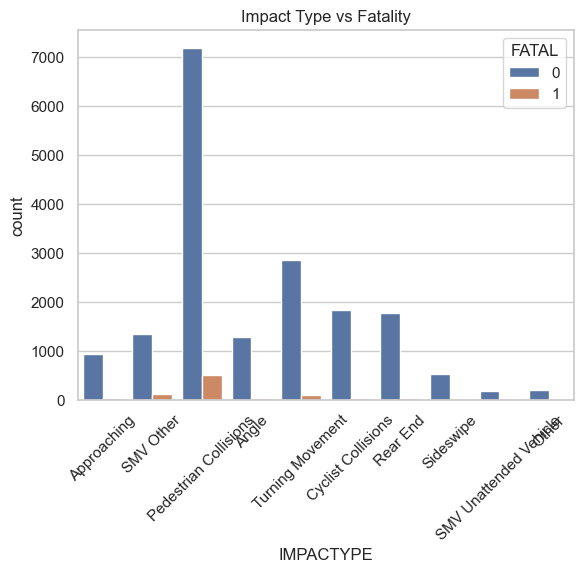

In [93]:
sns.countplot(data=group1_df, x='IMPACTYPE', hue='FATAL')
plt.xticks(rotation=45)
plt.title("Impact Type vs Fatality")
plt.show()

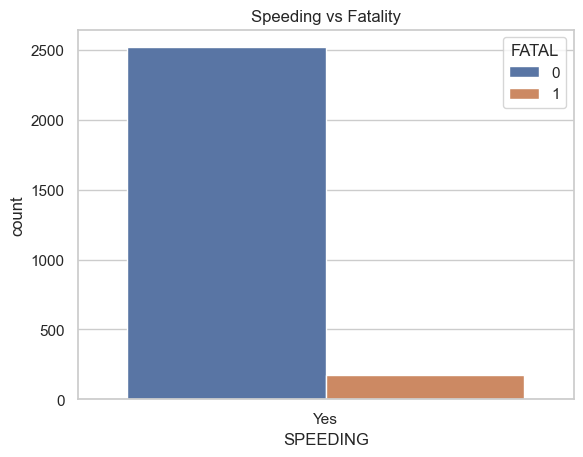

In [94]:
sns.countplot(data=group1_df, x='SPEEDING', hue='FATAL')
plt.title("Speeding vs Fatality")
plt.show()

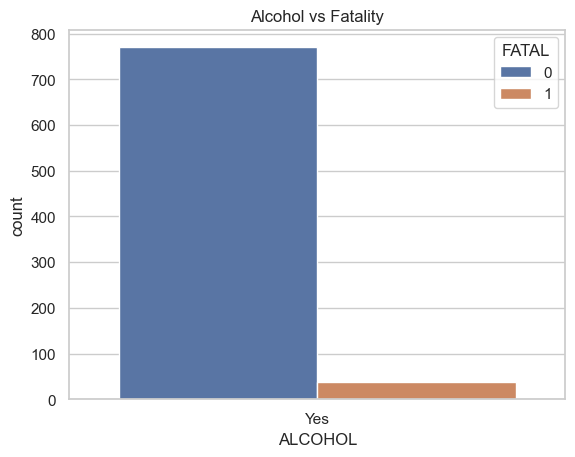

In [95]:
sns.countplot(data=group1_df, x='ALCOHOL', hue='FATAL')
plt.title("Alcohol vs Fatality")
plt.show()

In [96]:
age_order = [
    '0 to 4', '5 to 9', '10 to 14', '15 to 19',
    '20 to 24', '25 to 29', '30 to 34', '35 to 39',
    '40 to 44', '45 to 49', '50 to 54', '55 to 59',
    '60 to 64', '65 to 69', '70 to 74', '75 to 79',
    '80 to 84', '85 to 89', '90 to 94'
]

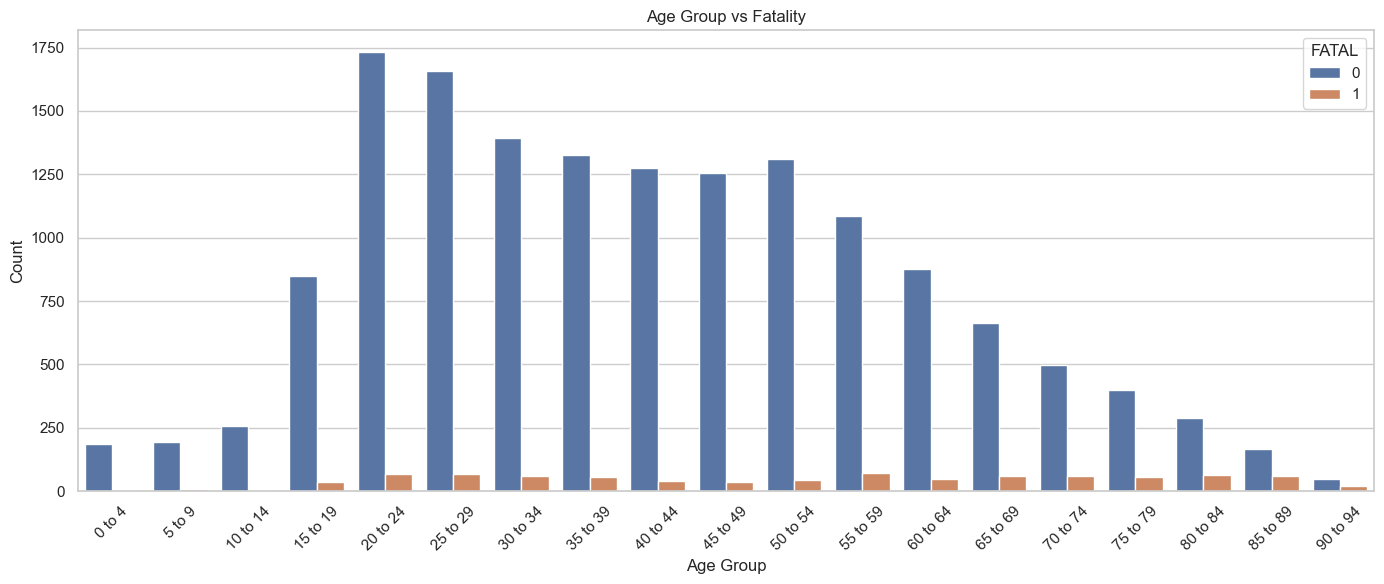

In [97]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=group1_df,
    x='INVAGE',
    hue='FATAL',
    order=age_order
)

plt.xticks(rotation=45)
plt.title("Age Group vs Fatality")
plt.xlabel("Age Group")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Dropping columns 

In [98]:
drop_columns = [
  "EMERG_VEH",
  "DISABILITY",
  "CYCCOND",
  "CYCACT",
  "CYCLISTYPE",
  "FATAL_NO",
  "TRSN_CITY_VEH",
  "TRUCK",
  
  "MOTORCYCLE",
  "CYCLIST",
  
  "PEDACT",
  "PEDTYPE",
  "PEDCOND",
  "OFFSET",
  "PASSENGER",
  "PEDESTRIAN",
  "DRIVCOND",
  "DRIVACT",
  "INJURY",
  "MANOEUVER"
]
group1_df['ACCLASS'].dropna(axis=0)

0        Non-Fatal Injury
1        Non-Fatal Injury
2        Non-Fatal Injury
3        Non-Fatal Injury
4        Non-Fatal Injury
               ...       
18952    Non-Fatal Injury
18953               Fatal
18954               Fatal
18955    Non-Fatal Injury
18956    Non-Fatal Injury
Name: ACCLASS, Length: 18956, dtype: str

In [99]:
group1_df = group1_df.drop(drop_columns, axis=1)

#### Converting some columns with missing values Yes and NaN with 0 and 1

In [100]:
binary_columns = ['ALCOHOL', 'SPEEDING', 'REDLIGHT', 'AG_DRIV']

In [101]:
group1_df[binary_columns] = group1_df[binary_columns].fillna(0) # Fill NaN -> 0

In [102]:
group1_df[binary_columns]= (group1_df[binary_columns]=="Yes").astype(int)  # Fill yes with 1

In [103]:
group1_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18957 entries, 0 to 18956
Data columns (total 36 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   OBJECTID           18957 non-null  int64  
 1   INDEX              18957 non-null  int64  
 2   ACCNUM             14027 non-null  float64
 3   DATE               18957 non-null  str    
 4   TIME               18957 non-null  int64  
 5   STREET1            18957 non-null  str    
 6   STREET2            17251 non-null  str    
 7   ROAD_CLASS         18471 non-null  str    
 8   DISTRICT           18728 non-null  str    
 9   LATITUDE           18957 non-null  float64
 10  LONGITUDE          18957 non-null  float64
 11  ACCLOC             13501 non-null  str    
 12  TRAFFCTL           18882 non-null  str    
 13  VISIBILITY         18933 non-null  str    
 14  LIGHT              18953 non-null  str    
 15  RDSFCOND           18928 non-null  str    
 16  ACCLASS            18956 non-null

In [104]:
cols_with_nulls = group1_df.columns[group1_df.isnull().any()].tolist()


In [106]:
# Filling missing values of categorical with mode 
row_modes = group1_df[cols_with_nulls].mode(axis=1)[0]

for col in cols_with_nulls:
    group1_df[col] = group1_df[col].fillna(row_modes)

In [107]:
group1_df.isnull().sum()  # now there is no missing values 

OBJECTID             0
INDEX                0
ACCNUM               0
DATE                 0
TIME                 0
STREET1              0
STREET2              0
ROAD_CLASS           0
DISTRICT             0
LATITUDE             0
LONGITUDE            0
ACCLOC               0
TRAFFCTL             0
VISIBILITY           0
LIGHT                0
RDSFCOND             0
ACCLASS              0
IMPACTYPE            0
INVTYPE              0
INVAGE               0
INITDIR              0
VEHTYPE              0
AUTOMOBILE           0
SPEEDING             0
AG_DRIV              0
REDLIGHT             0
ALCOHOL              0
HOOD_158             0
NEIGHBOURHOOD_158    0
HOOD_140             0
NEIGHBOURHOOD_140    0
DIVISION             0
x                    0
y                    0
FATAL                0
YEAR                 0
dtype: int64

In [108]:
idx = group1_df[group1_df['ACCLASS'] == "Yes"].index
group1_df = group1_df.drop(idx)

In [109]:
group1_df['ACCLASS'].unique()

array(['Non-Fatal Injury', 'Fatal', 'Property Damage O', 3001623085.0],
      dtype=object)

In [110]:
mapping = {
    'Non-Fatal Injury':0,
    'Fatal':1,
    'Property Damage O':2
}
group1_df["ACCLASS"] = group1_df["ACCLASS"].map(mapping)


In [111]:
group1_df['ACCLASS'].unique()

array([ 0.,  1.,  2., nan])

## chi-2 square technique for finding the correlated columns

In [112]:

cat_cols = group1_df.select_dtypes(include='object').columns.to_list()


/var/folders/76/602hdn1j1zl4qlrrt8jzxn2c0000gn/T/ipykernel_87492/2716390751.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = group1_df.select_dtypes(include='object').columns.to_list()


In [113]:
group1_df[cat_cols] = group1_df[cat_cols].astype(str)
from scipy.stats import chi2_contingency

In [114]:
from scipy.stats import chi2_contingency
import pandas as pd

results = []

# get all categorical columns except target
cat_cols = group1_df.select_dtypes(include='object').columns.tolist()
cat_cols = [col for col in cat_cols if col != 'ACCLASS']

for col in cat_cols:
    crosstab = pd.crosstab(index=group1_df[col], columns=group1_df['ACCLASS'])
    chi2, p_value, dof, expected = chi2_contingency(crosstab)
    
    results.append({
        'Feature': col,
        'Chi2 Score': round(chi2, 4),
        'P-Value': round(p_value, 4),
        'Degrees of Freedom': dof
    })

chi2_df = pd.DataFrame(results).sort_values('Chi2 Score', ascending=False)
print(chi2_df)

              Feature  Chi2 Score  P-Value  Degrees of Freedom
0              ACCNUM  30965.0259    0.000               10224
1                DATE  26036.5840    0.000                8254
3             STREET2  20787.3840    0.000                6560
2             STREET1  13530.0143    0.000                3882
15            VEHTYPE  11358.4386    0.000                2422
14            INITDIR   9515.5821    0.000                4910
16         AUTOMOBILE   6264.0577    0.000                1198
6              ACCLOC   5613.3473    0.000                3648
18  NEIGHBOURHOOD_158   1176.1713    0.000                 316
17           HOOD_158   1176.1713    0.000                 316
20  NEIGHBOURHOOD_140   1121.4464    0.000                 280
19           HOOD_140   1121.4464    0.000                 280
4          ROAD_CLASS    525.7318    0.000                 304
11          IMPACTYPE    429.9369    0.000                  36
5            DISTRICT    248.1560    0.009             

/var/folders/76/602hdn1j1zl4qlrrt8jzxn2c0000gn/T/ipykernel_87492/2656472483.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = group1_df.select_dtypes(include='object').columns.tolist()


In [115]:
good_features = chi2_df[chi2_df['P-Value'] < 0.05]['Feature'].tolist()
bad_features  = chi2_df[chi2_df['P-Value'] > 0.05]['Feature'].tolist()

print("Keep:", good_features)
print("Drop:", bad_features)

Keep: ['ACCNUM', 'DATE', 'STREET2', 'STREET1', 'VEHTYPE', 'INITDIR', 'AUTOMOBILE', 'ACCLOC', 'NEIGHBOURHOOD_158', 'HOOD_158', 'NEIGHBOURHOOD_140', 'HOOD_140', 'ROAD_CLASS', 'IMPACTYPE', 'DISTRICT', 'INVTYPE', 'RDSFCOND', 'INVAGE', 'VISIBILITY', 'DIVISION', 'LIGHT', 'TRAFFCTL']
Drop: []


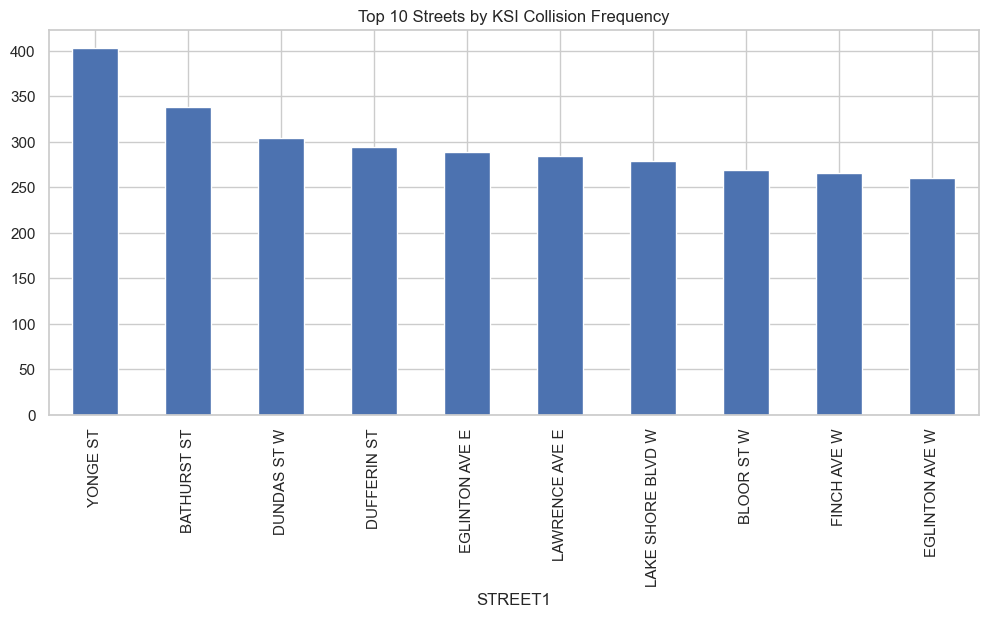

In [116]:
# Show this as an EDA insight only
top_streets = group1_df['STREET1'].value_counts().head(10)
top_streets.plot(kind='bar', figsize=(12,5))
plt.title("Top 10 Streets by KSI Collision Frequency")
plt.show()

In [117]:

print(group1_df['HOOD_158'].nunique())
print(group1_df['HOOD_140'].nunique())
print(group1_df['NEIGHBOURHOOD_158'].nunique())
print(group1_df['NEIGHBOURHOOD_140'].nunique())

print(group1_df[['HOOD_158', 'HOOD_140', 
          'NEIGHBOURHOOD_158', 'NEIGHBOURHOOD_140']].head(20))

159
141
159
141
   HOOD_158 HOOD_140     NEIGHBOURHOOD_158          NEIGHBOURHOOD_140
0        60       60      Woodbine-Lumsden      Woodbine-Lumsden (60)
1        60       60      Woodbine-Lumsden      Woodbine-Lumsden (60)
2        60       60      Woodbine-Lumsden      Woodbine-Lumsden (60)
3        60       60      Woodbine-Lumsden      Woodbine-Lumsden (60)
4        60       60      Woodbine-Lumsden      Woodbine-Lumsden (60)
5        60       60      Woodbine-Lumsden      Woodbine-Lumsden (60)
6        60       60      Woodbine-Lumsden      Woodbine-Lumsden (60)
7        60       60      Woodbine-Lumsden      Woodbine-Lumsden (60)
8        64       64     Woodbine Corridor     Woodbine Corridor (64)
9        64       64     Woodbine Corridor     Woodbine Corridor (64)
10       64       64     Woodbine Corridor     Woodbine Corridor (64)
11       64       64     Woodbine Corridor     Woodbine Corridor (64)
12       64       64     Woodbine Corridor     Woodbine Corridor (64)
13  

In [118]:

dropping = [
    'ACCNUM',            # just a row ID number
    'DATE',              # already extracted to YEAR/MONTH/HOUR
    'STREET1',           # text street name, too many unique values
    'STREET2',           # same issue
    'HOOD_158',          # redundant with HOOD_140
    'NEIGHBOURHOOD_158', # redundant with NEIGHBOURHOOD_140
    'NEIGHBOURHOOD_140', # too many unique text values
]

In [119]:
good_features =  [
    'VEHTYPE', 'INITDIR', 'AUTOMOBILE', 'ACCLOC',
    'HOOD_140', 'ROAD_CLASS', 'IMPACTYPE', 'DISTRICT',
    'INVTYPE', 'RDSFCOND', 'INVAGE', 'VISIBILITY',
    'DIVISION', 'LIGHT', 'TRAFFCTL'
]

In [120]:
# Convert to datetime 
group1_df['DATE'] = pd.to_datetime(group1_df['DATE'])


group1_df['YEAR']        = group1_df['DATE'].dt.year
group1_df['MONTH']       = group1_df['DATE'].dt.month
group1_df['HOUR']        = group1_df['DATE'].dt.hour
group1_df['DAY_OF_WEEK'] = group1_df['DATE'].dt.dayofweek


group1_df = group1_df.drop(columns=['DATE'])



In [121]:
final_features = good_features + ['YEAR', 'MONTH', 'HOUR', 
                                   'DAY_OF_WEEK', 'SPEEDING', 
                                   'ALCOHOL', 'AG_DRIV']

group1_df = group1_df.dropna(subset=['ACCLASS'])


X = group1_df[final_features]
y = group1_df['ACCLASS']

print("Final shape:", X.shape)

Final shape: (18956, 22)


In [122]:
print("y shape:", y.shape)

y shape: (18956,)


In [123]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (15164, 22)
Test size: (3792, 22)


In [124]:
cat_cols = X.select_dtypes(include='object').columns.tolist()
num_cols = X.select_dtypes(exclude='object').columns.tolist()

print("Categorical:", cat_cols)
print("Numerical:", num_cols)


Categorical: ['VEHTYPE', 'INITDIR', 'AUTOMOBILE', 'ACCLOC', 'HOOD_140', 'ROAD_CLASS', 'IMPACTYPE', 'DISTRICT', 'INVTYPE', 'RDSFCOND', 'INVAGE', 'VISIBILITY', 'DIVISION', 'LIGHT', 'TRAFFCTL']
Numerical: ['YEAR', 'MONTH', 'HOUR', 'DAY_OF_WEEK', 'SPEEDING', 'ALCOHOL', 'AG_DRIV']


/var/folders/76/602hdn1j1zl4qlrrt8jzxn2c0000gn/T/ipykernel_87492/4158373040.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include='object').columns.tolist()


In [125]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

In [126]:
# numerical pipeline
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# categorical pipeline
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

In [127]:
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [132]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [133]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train_processed, y_train)

In [134]:
print("Before balancing:\n", y_train.value_counts())
print("\nAfter balancing:\n", y_resampled.value_counts())

Before balancing:
 ACCLASS
0.0    13014
1.0     2136
2.0       14
Name: count, dtype: int64

After balancing:
 ACCLASS
0.0    13014
1.0    13014
2.0    13014
Name: count, dtype: int64
